In [1]:
# EXPERIMENT 1

In [3]:
# Experiment 1: Identifying Data Types and Preprocessing

import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Step 1: Load Dataset
df = pd.read_csv("diabetes_prediction_dataset.csv")

print("First 5 Rows:")
print(df.head())

# Step 2: Identify Data Types
print("\nData Types:")
print(df.dtypes)

# Step 3: Separate Numerical and Categorical Attributes
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("\nNumerical Columns:")
print(list(numerical_cols))

print("\nCategorical Columns:")
print(list(categorical_cols))

# Step 4: Convert Categorical Variables into Numerical Form
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("\nDataset After Encoding:")
print(df.head())

# Step 5: Remove Unnecessary Columns
# Remove if such columns exist
columns_to_drop = ['Patient ID', 'Name']

for col in columns_to_drop:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

print("\nColumns After Removal:")
print(df.columns)

# Step 6: Display Summary Statistics
print("\nSummary Statistics:")
print(df.describe())

# Step 7: Save Cleaned Dataset
df.to_csv("cleaned_diabetes_dataset.csv", index=False)

print("\nCleaned dataset saved as 'cleaned_diabetes_dataset.csv'")

First 5 Rows:
   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  

Data Types:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes  

In [4]:
# EXPERIMENT 2

In [8]:
# Experiment 2: Handling Missing Values

import pandas as pd

# Load Dataset
df = pd.read_csv("train.csv")

# Display dataset information
print("Dataset Shape:", df.shape)

# Missing values before handling
print("\nMissing Values Before:")
print(df.isnull().sum())

# Fill numerical columns with mean
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

# Fill categorical columns with mode
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Missing values after handling
print("\nMissing Values After:")
print(df.isnull().sum())

# Compare before and after
print("\nFirst 5 Rows After Preprocessing:")
print(df.head())

# Save cleaned dataset
df.to_csv("train_cleaned.csv", index=False)

print("\nCleaned dataset saved as train_cleaned.csv")

Dataset Shape: (891, 12)

Missing Values Before:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing Values After:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

First 5 Rows After Preprocessing:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38

In [9]:
# EXPERIMENT 3

In [10]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load Dataset
df = pd.read_csv("adult (2).csv")

print("First 5 Rows:")
print(df.head())

# Identify Categorical Columns
cat_cols = df.select_dtypes(include=['object']).columns

print("\nCategorical Columns:")
print(list(cat_cols))

# ---------------------------
# Label Encoding
# ---------------------------
label_df = df.copy()

le = LabelEncoder()

for col in cat_cols:
    label_df[col] = le.fit_transform(label_df[col].astype(str))

print("\nDataset After Label Encoding:")
print(label_df.head())

# Save Label Encoded Dataset
label_df.to_csv("adult_label_encoded.csv", index=False)

# ---------------------------
# One-Hot Encoding
# ---------------------------
onehot_df = pd.get_dummies(df, columns=cat_cols)

print("\nDataset After One-Hot Encoding:")
print(onehot_df.head())

# Save One-Hot Encoded Dataset
onehot_df.to_csv("adult_onehot_encoded.csv", index=False)

# Compare Shapes
print("\nOriginal Shape:", df.shape)
print("Label Encoded Shape:", label_df.shape)
print("One-Hot Encoded Shape:", onehot_df.shape)

First 5 Rows:
   39          State-gov   77516   Bachelors   13        Never-married  \
0  50   Self-emp-not-inc   83311   Bachelors   13   Married-civ-spouse   
1  38            Private  215646     HS-grad    9             Divorced   
2  53            Private  234721        11th    7   Married-civ-spouse   
3  28            Private  338409   Bachelors   13   Married-civ-spouse   
4  37            Private  284582     Masters   14   Married-civ-spouse   

         Adm-clerical   Not-in-family   White     Male   2174   0   40  \
0     Exec-managerial         Husband   White     Male      0   0   13   
1   Handlers-cleaners   Not-in-family   White     Male      0   0   40   
2   Handlers-cleaners         Husband   Black     Male      0   0   40   
3      Prof-specialty            Wife   Black   Female      0   0   40   
4     Exec-managerial            Wife   White   Female      0   0   40   

    United-States   <=50K  
0   United-States   <=50K  
1   United-States   <=50K  
2   United-S

In [11]:
# EXPERIMENT 4

First 5 Rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Original Data:
   MedInc
0  8.3252
1  8.3014
2  7.2574
3  5.6431
4  3.8462

After Min-Max Scaling:
     MedInc
0  0.539668
1  0.538027
2  0.466028
3  0.354699
4  0.230776

After Standardization:
     MedInc
0  2.344766
1  2.332238
2  1.782699
3  0.932968
4 -0.012881


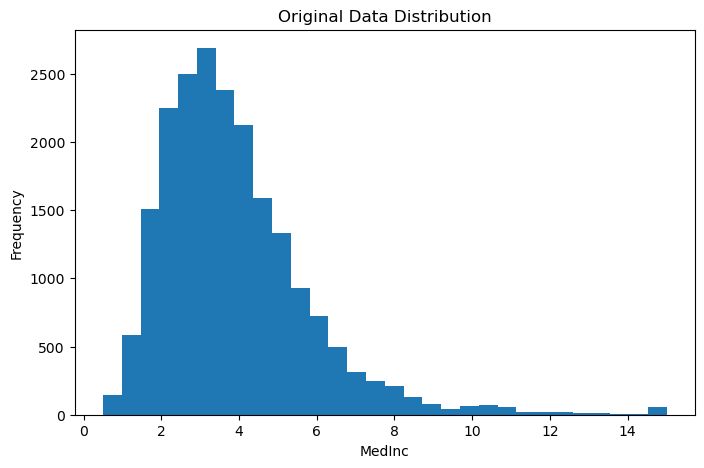

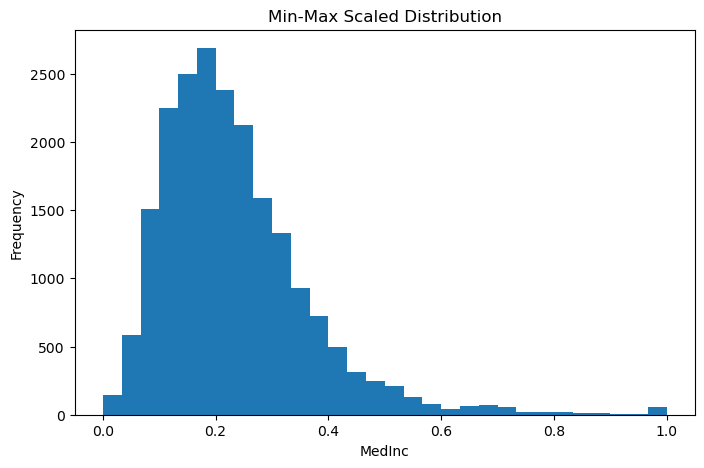

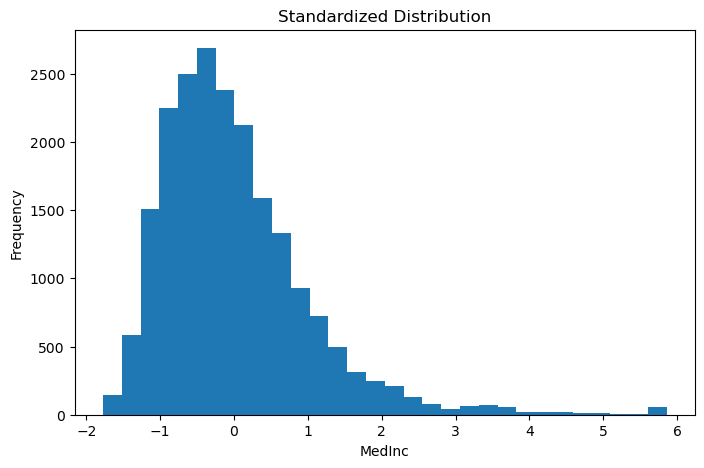

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Load California Housing Dataset
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)

print("First 5 Rows:")
print(df.head())

# Select a column for comparison
column = "MedInc"

# ---------------------------
# Min-Max Scaling
# ---------------------------
minmax = MinMaxScaler()
df_minmax = pd.DataFrame(
    minmax.fit_transform(df),
    columns=df.columns
)

# ---------------------------
# Standardization
# ---------------------------
standard = StandardScaler()
df_standard = pd.DataFrame(
    standard.fit_transform(df),
    columns=df.columns
)

# ---------------------------
# Compare Values
# ---------------------------
print("\nOriginal Data:")
print(df[[column]].head())

print("\nAfter Min-Max Scaling:")
print(df_minmax[[column]].head())

print("\nAfter Standardization:")
print(df_standard[[column]].head())

# ---------------------------
# Plot Distributions
# ---------------------------

plt.figure(figsize=(8,5))
plt.hist(df[column], bins=30)
plt.title("Original Data Distribution")
plt.xlabel(column)
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8,5))
plt.hist(df_minmax[column], bins=30)
plt.title("Min-Max Scaled Distribution")
plt.xlabel(column)
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8,5))
plt.hist(df_standard[column], bins=30)
plt.title("Standardized Distribution")
plt.xlabel(column)
plt.ylabel("Frequency")
plt.show()

In [16]:
# EXPERIMENT 5

First 5 Rows:
   1  14.23  1.71  2.43  15.6  127   2.8  3.06   .28  2.29  5.64  1.04  3.92  \
0  1  13.20  1.78  2.14  11.2  100  2.65  2.76  0.26  1.28  4.38  1.05  3.40   
1  1  13.16  2.36  2.67  18.6  101  2.80  3.24  0.30  2.81  5.68  1.03  3.17   
2  1  14.37  1.95  2.50  16.8  113  3.85  3.49  0.24  2.18  7.80  0.86  3.45   
3  1  13.24  2.59  2.87  21.0  118  2.80  2.69  0.39  1.82  4.32  1.04  2.93   
4  1  14.20  1.76  2.45  15.2  112  3.27  3.39  0.34  1.97  6.75  1.05  2.85   

   1065  
0  1050  
1  1185  
2  1480  
3   735  
4  1450  

Original Shape: (177, 14)

PCA Transformed Data:
        PC1       PC2
0 -2.551769 -0.301013
1 -2.803540  1.064472
2 -3.927293  2.809760
3 -1.422861  0.887657
4 -3.293710  2.172936

Explained Variance Ratio:
[0.39335457 0.17867003]

Total Variance Explained:
0.5720246004570532


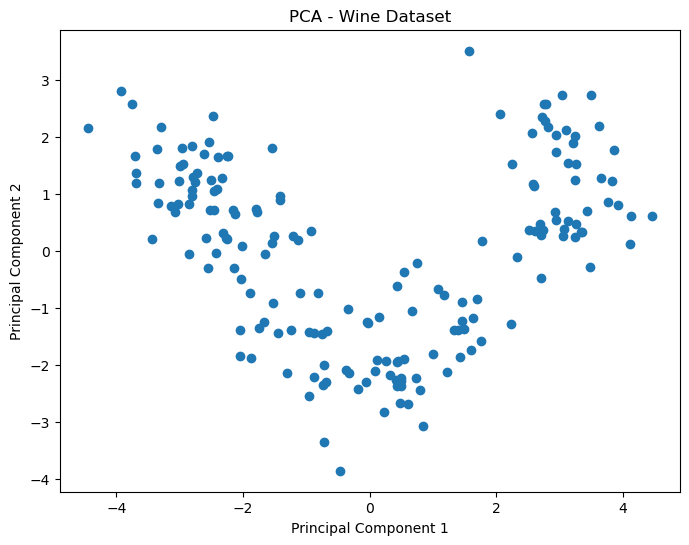


Original Dimensions: 14
Reduced Dimensions: 2


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load Dataset
df = pd.read_csv("wine.csv")

print("First 5 Rows:")
print(df.head())

# Display dataset shape
print("\nOriginal Shape:", df.shape)

# Select only numerical columns
X = df.select_dtypes(include=['int64', 'float64'])

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA (Reduce to 2 Dimensions)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create PCA DataFrame
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

print("\nPCA Transformed Data:")
print(pca_df.head())

# Explained Variance Ratio
print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Variance Explained:")
print(sum(pca.explained_variance_ratio_))

# Scatter Plot
plt.figure(figsize=(8,6))
plt.scatter(pca_df['PC1'], pca_df['PC2'])
plt.title("PCA - Wine Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

print("\nOriginal Dimensions:", X.shape[1])
print("Reduced Dimensions:", pca_df.shape[1])

In [19]:
# EXPERIMENT 6

In [21]:
import pandas as pd
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load Dataset
df = pd.read_csv("wdbc.csv")

# Display column names
print("Columns in Dataset:")
print(df.columns.tolist())

# Remove ID column if present
for col in ['id', 'ID', 'Id']:
    if col in df.columns:
        df = df.drop(col, axis=1)

# ==============================
# CHANGE THIS COLUMN NAME IF NEEDED
# ==============================
target_column = df.columns[1]   # Change if your target column is different

print("\nTarget Column Selected:", target_column)

# Target Variable
y = df[target_column]

# Convert categorical target to numerical if needed
if y.dtype == 'object':
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    y = le.fit_transform(y)

# Features
X = df.drop(target_column, axis=1)

# -----------------------------
# Accuracy Before Feature Selection
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=10000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc_before = accuracy_score(y_test, y_pred)

print("\nAccuracy Before Feature Selection:")
print(acc_before)

# -----------------------------
# Select Top 10 Features
# -----------------------------
selector = SelectKBest(score_func=f_classif, k=10)

X_new = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

print("\nTop 10 Selected Features:")
for feature in selected_features:
    print(feature)

# -----------------------------
# Accuracy After Feature Selection
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_new, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc_after = accuracy_score(y_test, y_pred)

print("\nAccuracy After Feature Selection:")
print(acc_after)

print("\nAccuracy Improvement:")
print(acc_after - acc_before)

Columns in Dataset:
['842302', 'M', '17.99', '10.38', '122.8', '1001', '0.1184', '0.2776', '0.3001', '0.1471', '0.2419', '0.07871', '1.095', '0.9053', '8.589', '153.4', '0.006399', '0.04904', '0.05373', '0.01587', '0.03003', '0.006193', '25.38', '17.33', '184.6', '2019', '0.1622', '0.6656', '0.7119', '0.2654', '0.4601', '0.1189']

Target Column Selected: M

Accuracy Before Feature Selection:
0.9210526315789473

Top 10 Selected Features:
17.99
122.8
1001
0.3001
0.1471
25.38
184.6
2019
0.7119
0.2654

Accuracy After Feature Selection:
0.9210526315789473

Accuracy Improvement:
0.0


In [22]:
# EXPERIMENT 7

First 5 Rows:
   Unnamed: 0  YearsExperience   Salary
0           0              1.2  39344.0
1           1              1.4  46206.0
2           2              1.6  37732.0
3           3              2.1  43526.0
4           4              2.3  39892.0

Columns:
Index(['Unnamed: 0', 'YearsExperience', 'Salary'], dtype='object')


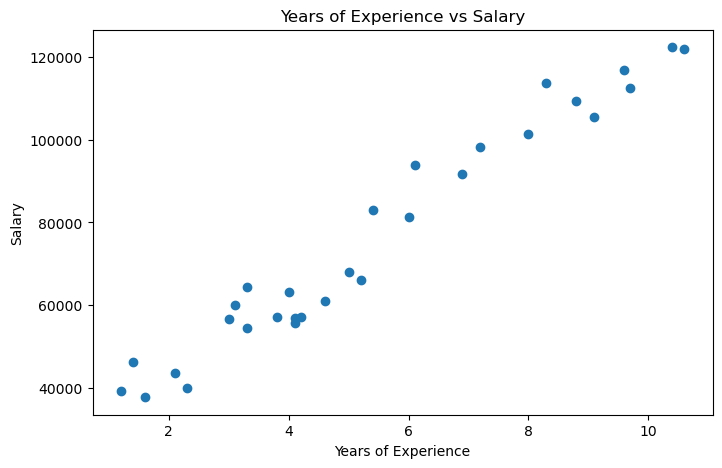


Model Evaluation
MAE : 6286.453830757745
MSE : 49830096.855908334
R² Score : 0.9024461774180498

Predicted Salary for 5 Years Experience:
71499.2780946286


C:\Users\anits\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


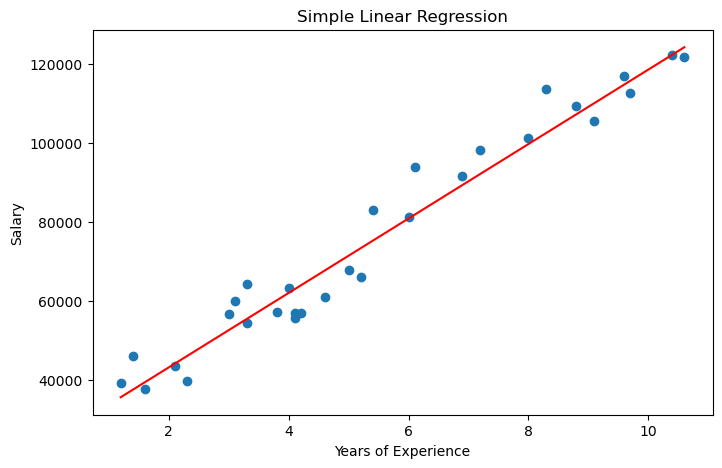


Regression Equation:
Salary = 9423.82 * Experience + 24380.20


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Dataset
df = pd.read_csv("Salary_dataset.csv")

print("First 5 Rows:")
print(df.head())

print("\nColumns:")
print(df.columns)

# Features and Target
X = df.iloc[:, 1:2]   # YearsExperience
y = df.iloc[:, 2]     # Salary

# Scatter Plot
plt.figure(figsize=(8,5))
plt.scatter(X, y)
plt.title("Years of Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation")
print("MAE :", mae)
print("MSE :", mse)
print("R² Score :", r2)

# Predict Salary for New Employee
experience = [[5]]
predicted_salary = model.predict(experience)

print("\nPredicted Salary for 5 Years Experience:")
print(predicted_salary[0])

# Regression Line
plt.figure(figsize=(8,5))
plt.scatter(X, y)

plt.plot(
    X,
    model.predict(X),
    color='red'
)

plt.title("Simple Linear Regression")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

# Equation of Line
print("\nRegression Equation:")
print(f"Salary = {model.coef_[0]:.2f} * Experience + {model.intercept_:.2f}")

In [24]:
# EXPERIMENT 8

Dataset Shape: (395, 33)

Columns:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


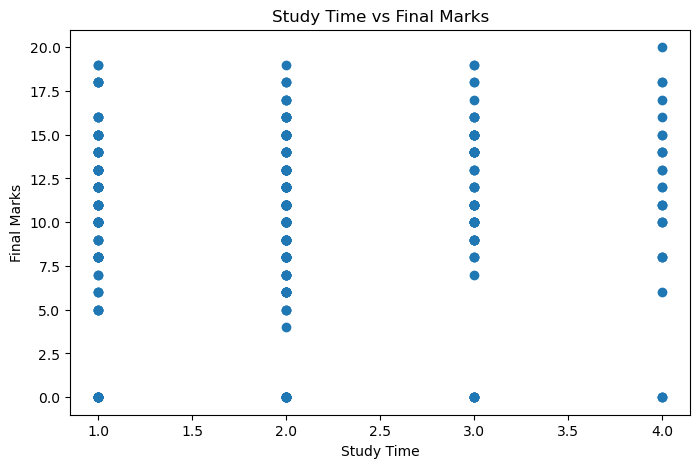


MAE = 3.678962967623515
MSE = 21.492916098598933
R² Score = -0.04817686190225934

Predicted Marks:
5 Hours -> 12.57
7 Hours -> 14.08
10 Hours -> 16.36


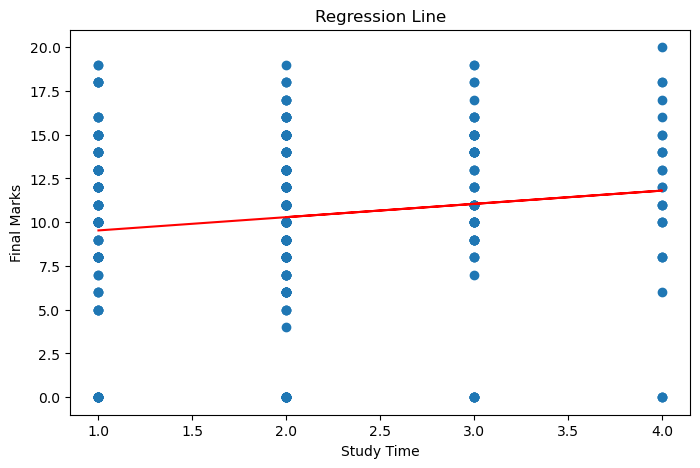


Regression Equation:
G3 = 0.76 * studytime + 8.77


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Read CSV with semicolon separator
df = pd.read_csv("student-mat.csv", sep=';')

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

# Input Feature = studytime
X = df[['studytime']]

# Target Variable = Final Grade
y = df['G3']

# Scatter Plot
plt.figure(figsize=(8,5))
plt.scatter(X, y)
plt.title("Study Time vs Final Marks")
plt.xlabel("Study Time")
plt.ylabel("Final Marks")
plt.show()

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation Metrics
print("\nMAE =", mean_absolute_error(y_test, y_pred))
print("MSE =", mean_squared_error(y_test, y_pred))
print("R² Score =", r2_score(y_test, y_pred))

# Predict Marks for 5, 7, 10 Hours
new_data = pd.DataFrame({'studytime':[5,7,10]})

predictions = model.predict(new_data)

print("\nPredicted Marks:")
for h, m in zip([5,7,10], predictions):
    print(f"{h} Hours -> {m:.2f}")

# Regression Line
plt.figure(figsize=(8,5))
plt.scatter(X, y)

plt.plot(
    X,
    model.predict(X),
    color='red'
)

plt.title("Regression Line")
plt.xlabel("Study Time")
plt.ylabel("Final Marks")
plt.show()

# Equation
print("\nRegression Equation:")
print(f"G3 = {model.coef_[0]:.2f} * studytime + {model.intercept_:.2f}")